1. Cargando y filtrando datos...
-> Estrellas retenidas (PoE > 5): 11370

Ejecutando Modelos de Clasificación...

Generando panel visual 5x2 Dark Mode...


Dibujando gráficas: 100%|██████████| 5/5 [00:00<00:00, 28.97it/s]



¡Proceso finalizado con éxito! Gráficos guardados en 'comparativa_darkmode_astroml.png'.


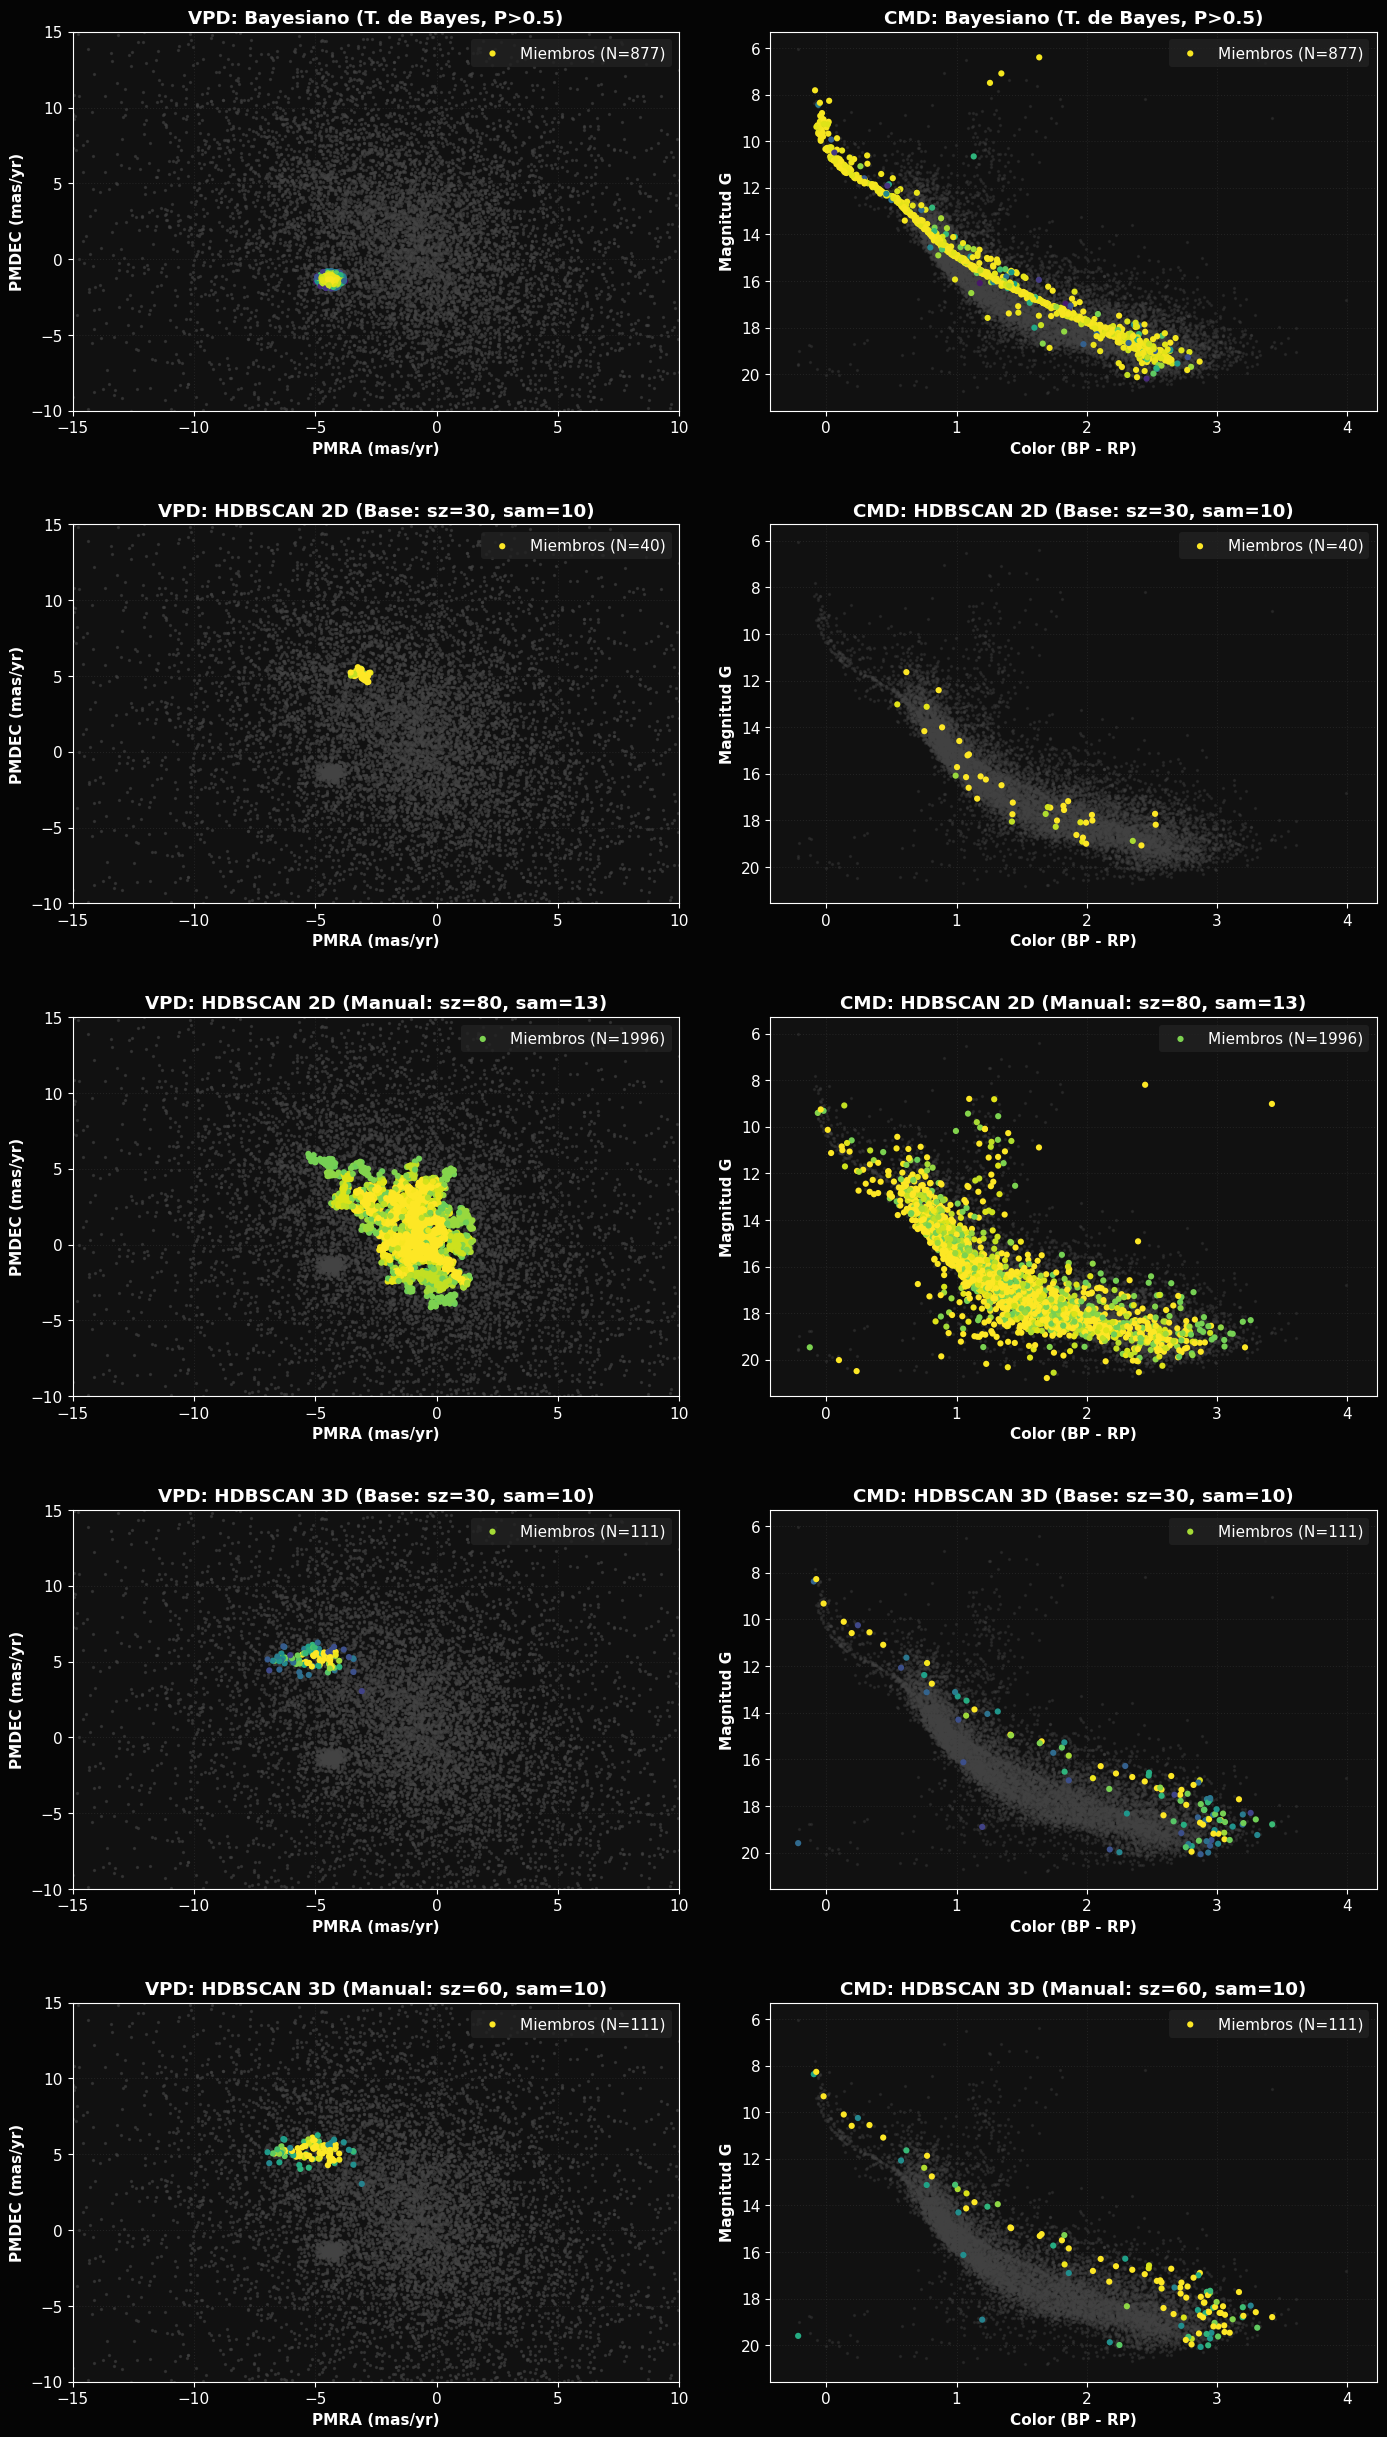

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.optimize import minimize
import warnings
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import HDBSCAN
from sklearn.metrics import silhouette_score # Nota: Importado pero no utilizado en este script

warnings.filterwarnings('ignore')

# ==========================================
# HIPERPARÁMETROS GLOBALES
# ==========================================
# Probabilidad mínima requerida para clasificar una estrella como miembro del cúmulo
UMBRAL_PROB = 0.5       

# ==========================================
# FUNCIÓN DE VEROSIMILITUD (BAYESIANA)
# ==========================================
def neg_log_likelihood(theta, pmra, pmdec):
    """
    Calcula el logaritmo negativo de la función de verosimilitud (Negative Log-Likelihood) 
    para un modelo de mezcla gaussiana bidimensional (Gaussian Mixture Model).
    Asume dos poblaciones: miembros del cúmulo (distribución circular) y estrellas de campo (distribución elíptica).
    
    Parámetros (theta):
    - nc: Fracción de estrellas que pertenecen al cúmulo.
    - mu_xc, mu_yc: Movimientos propios centrales del cúmulo (PMRA, PMDEC).
    - sig_c: Dispersión de velocidades intrínseca del cúmulo.
    - mu_xf, mu_yf: Movimientos propios promedio de las estrellas de campo.
    - sig_fx, sig_fy: Dispersiones de velocidad del campo en AR y Dec.
    - rho: Coeficiente de correlación cruzada de las estrellas de campo.
    """
    nc, mu_xc, mu_yc, sig_c, mu_xf, mu_yf, sig_fx, sig_fy, rho = theta
    
    # Restricciones físicas y matemáticas para evitar inestabilidades en la optimización
    if nc <= 0 or nc >= 1 or sig_c <= 0 or sig_fx <= 0 or sig_fy <= 0 or rho <= -1 or rho >= 1:
        return np.inf
    
    # 1. Función de Densidad de Probabilidad (PDF) para el Cúmulo (Gaussiana Isotrópica)
    z_c = ((pmra - mu_xc)**2 + (pmdec - mu_yc)**2) / (sig_c**2)
    pdf_c = (1.0 / (2 * np.pi * sig_c**2)) * np.exp(-0.5 * z_c)
    
    # 2. Función de Densidad de Probabilidad (PDF) para el Campo (Gaussiana Bivariada Correlacionada)
    z_f = (((pmra - mu_xf)**2 / sig_fx**2) - 2 * rho * (pmra - mu_xf) * (pmdec - mu_yf) / (sig_fx * sig_fy) + ((pmdec - mu_yf)**2 / sig_fy**2))
    factor_f = 1.0 / (2 * np.pi * sig_fx * sig_fy * np.sqrt(1 - rho**2))
    pdf_f = factor_f * np.exp(-0.5 * z_f / (1 - rho**2))
    
    # Verosimilitud total: suma ponderada de ambas poblaciones
    L = nc * pdf_c + (1 - nc) * pdf_f
    
    # Retorna el NLL (se usa 1e-15 para evitar log(0))
    return -np.sum(np.log(np.maximum(L, 1e-15)))

# ==========================================
# 1. CARGA DE DATOS Y FILTRADO
# ==========================================
print("1. Cargando y filtrando datos...")
df = pd.read_csv(r"C:\Users\santi\Downloads\lab 3 astro ml\M41_query_result_full.csv")

# Eliminar valores nulos en columnas astrométricas y fotométricas críticas
df = df.dropna(subset=['pmra', 'pmdec', 'parallax', 'phot_g_mean_mag', 'bp_rp'])

# Filtro de calidad astrométrica: Parallax Over Error (PoE) > 5 para asegurar distancias confiables
df_clean = df[df['parallax_over_error'] > 5].copy()
print(f"-> Estrellas retenidas (PoE > 5): {len(df_clean)}")

# ==========================================
# 2. PREPARACIÓN DE ESPACIOS DE FASES
# ==========================================
# El RobustScaler es ideal en astrometría para mitigar la influencia de estrellas de campo extremas (outliers)
scaler_2d = RobustScaler()
X_2d = scaler_2d.fit_transform(df_clean[['pmra', 'pmdec']]) # Espacio puramente cinemático

scaler_3d = RobustScaler()
X_3d = scaler_3d.fit_transform(df_clean[['pmra', 'pmdec', 'parallax']]) # Espacio cinemático + distancia espacial

# Coordenadas aproximadas esperadas del cúmulo M41 en el espacio de movimientos propios (PMRA, PMDEC)
coord_m41 = [-3.3, 5.5] 

# ==========================================
# 3. DEFINICIÓN MANUAL DE PARÁMETROS HDBSCAN
# ==========================================
# Se eliminó Optuna. En su lugar, definimos los parámetros "óptimos" manualmente
# basándonos en corridas previas o conocimiento del dominio.
params_opt_2d = {'min_cluster_size': 80, 'min_samples': 13}
params_opt_3d = {'min_cluster_size': 60, 'min_samples': 10}

# ==========================================
# 4. EJECUCIÓN DE MODELOS
# ==========================================
print("\nEjecutando Modelos de Clasificación...")

# ------------------------------------------------
# A. Método Bayesiano (Modelado Analítico)
# ------------------------------------------------
pmra_vals = df_clean['pmra'].values
pmdec_vals = df_clean['pmdec'].values

# Estimación inicial de los centros geométricos usando un histograma 2D para acelerar la convergencia
H, xedges, yedges = np.histogram2d(pmra_vals, pmdec_vals, bins=100, range=[[-15, 5], [-5, 15]])
x_idx, y_idx = np.unravel_index(np.argmax(H), H.shape)
mu_xc_init = (xedges[x_idx] + xedges[x_idx+1]) / 2
mu_yc_init = (yedges[y_idx] + yedges[y_idx+1]) / 2

# Valores iniciales (theta0) y límites (bounds) para la optimización L-BFGS-B
theta0 = [0.05, mu_xc_init, mu_yc_init, 0.5, np.median(pmra_vals), np.median(pmdec_vals), np.std(pmra_vals), np.std(pmdec_vals), 0.0]
bounds = [(0.001, 0.5), (-20, 20), (-20, 20), (0.01, 3.0), (-30, 30), (-30, 30), (1.0, 30.0), (1.0, 30.0), (-0.99, 0.99)]

# Optimización de la función NLL
result = minimize(neg_log_likelihood, theta0, args=(pmra_vals, pmdec_vals), method='L-BFGS-B', bounds=bounds)
nc, mu_xc, mu_yc, sig_c, mu_xf, mu_yf, sig_fx, sig_fy, rho = result.x

# Reconstrucción de las probabilidades a posteriori usando el Teorema de Bayes
z_c = ((pmra_vals - mu_xc)**2 + (pmdec_vals - mu_yc)**2) / (sig_c**2)
pdf_c = (1.0 / (2 * np.pi * sig_c**2)) * np.exp(-0.5 * z_c)
z_f = (((pmra_vals - mu_xf)**2 / sig_fx**2) - 2 * rho * (pmra_vals - mu_xf) * (pmdec_vals - mu_yf) / (sig_fx * sig_fy) + ((pmdec_vals - mu_yf)**2 / sig_fy**2))
pdf_f = (1.0 / (2 * np.pi * sig_fx * sig_fy * np.sqrt(1 - rho**2))) * np.exp(-0.5 * z_f / (1 - rho**2))

# Cálculo de probabilidad individual de membresía
df_clean['p_member_bayes'] = (nc * pdf_c) / (nc * pdf_c + (1 - nc) * pdf_f + 1e-15)
mask_bayes = df_clean['p_member_bayes'] > UMBRAL_PROB
probs_bayes = df_clean['p_member_bayes'].values

# ------------------------------------------------
# B. Función Auxiliar para correr HDBSCAN (Machine Learning no supervisado)
# ------------------------------------------------
def aplicar_hdbscan(X, params, umbral=UMBRAL_PROB):
    """
    Instancia y ajusta un modelo HDBSCAN sobre el espacio de características X.
    Identifica el clúster principal midiendo la distancia de los centroides 
    a las coordenadas esperadas del cúmulo M41.
    """
    # cluster_selection_method='eom' (Excess of Mass) es estándar para encontrar estructuras densas
    hdb = HDBSCAN(min_cluster_size=params['min_cluster_size'], min_samples=params['min_samples'], cluster_selection_method='eom')
    labels = hdb.fit_predict(X)
    probs = hdb.probabilities_
    
    unique_labels = set(labels) - {-1} # Excluir el ruido (-1)
    if not unique_labels:
        return np.zeros(len(X), dtype=bool), np.zeros(len(X))
        
    # Calcular centroides en el espacio físico original (PMRA, PMDEC) para cada clúster encontrado
    cluster_centers = {l: np.mean(df_clean.iloc[labels == l][['pmra', 'pmdec']].values, axis=0) for l in unique_labels}
    
    # Asumir que el clúster principal es el más cercano a las coordenadas cinemáticas conocidas de M41
    main_label = min(cluster_centers, key=lambda l: np.sum((cluster_centers[l] - coord_m41)**2))
    
    is_main = (labels == main_label)
    mask = is_main & (probs > umbral)
    return mask, probs

# Ejecución de HDBSCAN en diferentes configuraciones (2D vs 3D, Base vs Optimizado)
params_guess = {'min_cluster_size': 30, 'min_samples': 10}
mask_2d_int, probs_2d_int = aplicar_hdbscan(X_2d, params_guess)
mask_2d_opt, probs_2d_opt = aplicar_hdbscan(X_2d, params_opt_2d)
mask_3d_int, probs_3d_int = aplicar_hdbscan(X_3d, params_guess)
mask_3d_opt, probs_3d_opt = aplicar_hdbscan(X_3d, params_opt_3d)

# ==========================================
# 5. VISUALIZACIÓN CIENTÍFICA (DARK MODE)
# ==========================================
print("\nGenerando panel visual 5x2 Dark Mode...")

# Aplicar estilo oscuro de Matplotlib para presentaciones científicas o alto contraste
plt.style.use('dark_background')
plt.rcParams.update({
    'font.size': 11,
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
    'axes.facecolor': '#111111',   # Fondo interno de las gráficas
    'figure.facecolor': '#050505', # Fondo global de la figura
    'grid.color': '#333333'        # Color sutil para la cuadrícula
})

# Creación de matriz de subgráficos 5 filas (métodos) x 2 columnas (VPD y CMD)
fig, axes = plt.subplots(5, 2, figsize=(14, 25))

# Estructuración iterativa de los escenarios para automatizar el trazado
scenarios = [
    (f"Bayesiano (T. de Bayes, P>{UMBRAL_PROB})", mask_bayes, probs_bayes),
    (f"HDBSCAN 2D (Base: sz=30, sam=10)", mask_2d_int, probs_2d_int),
    (f"HDBSCAN 2D (Manual: sz={params_opt_2d['min_cluster_size']}, sam={params_opt_2d['min_samples']})", mask_2d_opt, probs_2d_opt),
    (f"HDBSCAN 3D (Base: sz=30, sam=10)", mask_3d_int, probs_3d_int),
    (f"HDBSCAN 3D (Manual: sz={params_opt_3d['min_cluster_size']}, sam={params_opt_3d['min_samples']})", mask_3d_opt, probs_3d_opt)
]

for i, (title, mask, probs) in enumerate(tqdm(scenarios, desc="Dibujando gráficas")):
    
    # ----------------------------------------
    # Panel Izquierdo: Vector Point Diagram (VPD)
    # Visualiza la cinemática de las estrellas (Movimientos Propios)
    # ----------------------------------------
    ax_vpd = axes[i, 0]
    ax_vpd.grid(True, linestyle=':', alpha=0.5, zorder=0)
    
    # Contexto visual: Estrellas de campo de fondo
    ax_vpd.scatter(df_clean['pmra'], df_clean['pmdec'], c='#444444', s=2, alpha=0.5, zorder=1)
    
    # Destacar los miembros identificados con mapa de color basado en la probabilidad
    if mask.sum() > 0:
        ax_vpd.scatter(
            df_clean.loc[mask, 'pmra'], df_clean.loc[mask, 'pmdec'], 
            c=probs[mask], cmap='viridis', s=20, alpha=1.0, edgecolor='none', 
            zorder=3, vmin=UMBRAL_PROB, vmax=1.0, label=f'Miembros (N={mask.sum()})'
        )
    ax_vpd.set_title(f"VPD: {title}")
    ax_vpd.set_xlabel("PMRA (mas/yr)")
    ax_vpd.set_ylabel("PMDEC (mas/yr)")
    ax_vpd.set_xlim(-15, 10)
    ax_vpd.set_ylim(-10, 15)
    
    if mask.sum() > 0:
        legend = ax_vpd.legend(loc='upper right', frameon=True)
        legend.get_frame().set_facecolor('#222222')
        legend.get_frame().set_edgecolor('none')
        
    # ----------------------------------------
    # Panel Derecho: Diagrama Color-Magnitud (CMD)
    # Visualiza propiedades fotométricas/evolución estelar (Diagrama HR observacional)
    # ----------------------------------------
    ax_cmd = axes[i, 1]
    ax_cmd.grid(True, linestyle=':', alpha=0.5, zorder=0)
    
    # Contexto visual: Estrellas de campo de fondo
    ax_cmd.scatter(df_clean['bp_rp'], df_clean['phot_g_mean_mag'], c='#444444', s=2, alpha=0.3, zorder=1)
    
    # Trazar secuencias evolutivas (Main Sequence, Red Clump, etc.) de los miembros detectados
    if mask.sum() > 0:
        ax_cmd.scatter(
            df_clean.loc[mask, 'bp_rp'], df_clean.loc[mask, 'phot_g_mean_mag'], 
            c=probs[mask], cmap='viridis', s=20, alpha=1.0, edgecolor='none', 
            zorder=3, vmin=UMBRAL_PROB, vmax=1.0, label=f'Miembros (N={mask.sum()})'
        )
    ax_cmd.invert_yaxis() # Las magnitudes astronómicas se grafican al revés (menor es más brillante)
    ax_cmd.set_title(f"CMD: {title}")
    ax_cmd.set_xlabel("Color (BP - RP)")
    ax_cmd.set_ylabel("Magnitud G")
    
    if mask.sum() > 0:
        legend = ax_cmd.legend(loc='upper right', frameon=True)
        legend.get_frame().set_facecolor('#222222')
        legend.get_frame().set_edgecolor('none')

# Ajustes finales de diseño y exportación del gráfico
plt.tight_layout()
plt.subplots_adjust(top=0.97, bottom=0.03, hspace=0.3, wspace=0.15)
plt.savefig('comparativa_darkmode_astroml.png', dpi=400, bbox_inches='tight')
print("\n¡Proceso finalizado con éxito! Gráficos guardados en 'comparativa_darkmode_astroml.png'.")

Dibujando todos los clusters: 100%|██████████| 4/4 [00:10<00:00,  2.58s/it]



¡Gráficos de todos los clusters guardados en 'todos_los_clusters_hdbscan_darkmode_con_centro.png'!


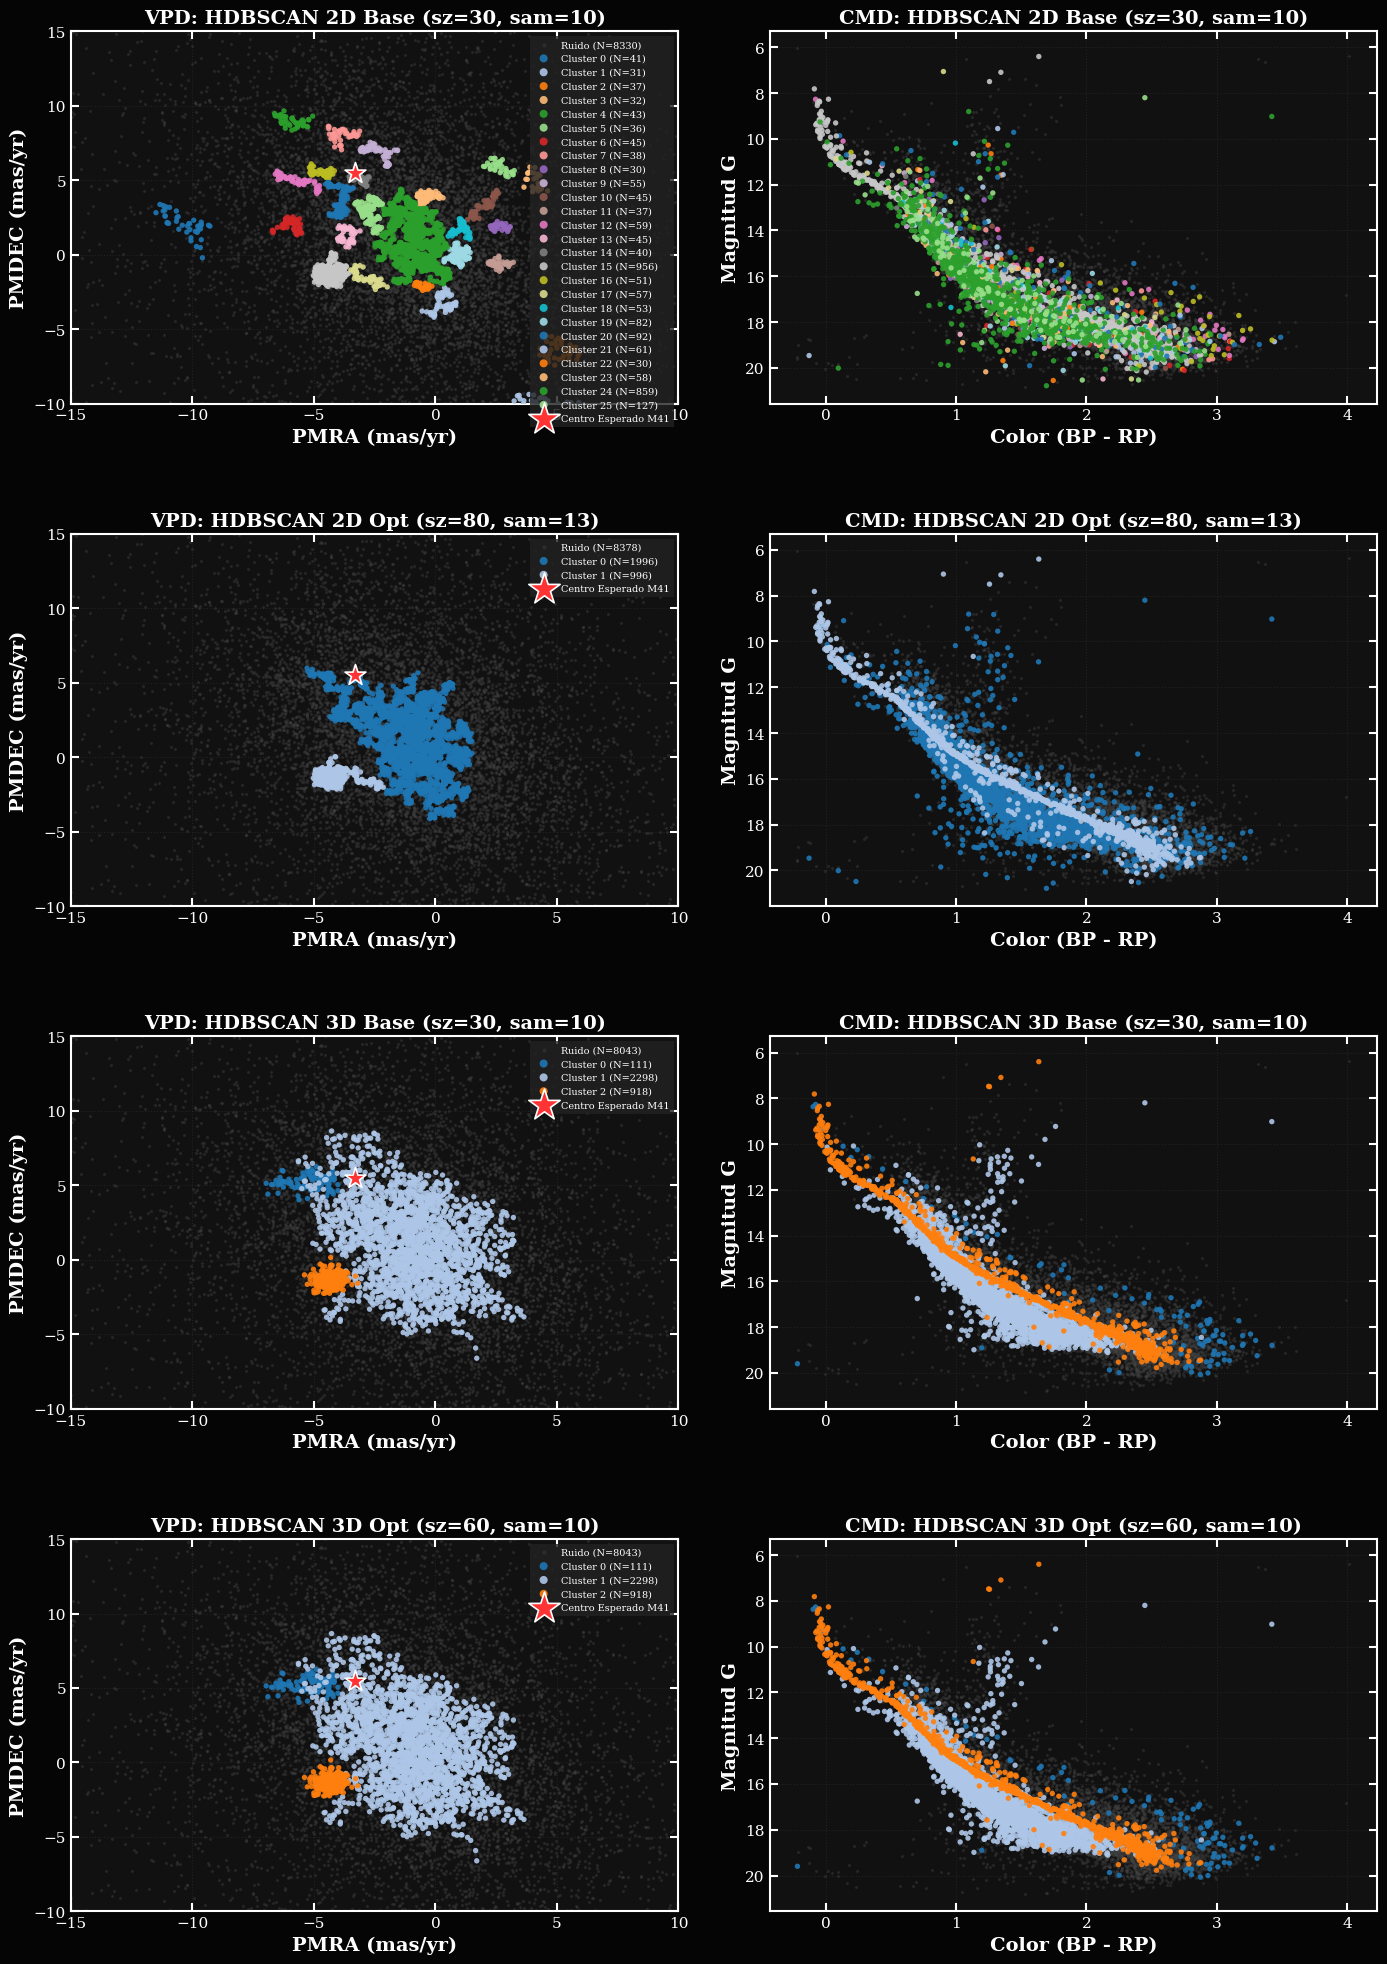

In [9]:
def plot_all_clusters(X, df, params, title_prefix, ax_vpd, ax_cmd, center_coords):
    """Ejecuta HDBSCAN y grafica todos los clusters detectados sin filtrar, marcando el centro conocido."""
    
    # 1. Ejecutar HDBSCAN
    hdb = HDBSCAN(min_cluster_size=params['min_cluster_size'], 
                  min_samples=params['min_samples'], 
                  cluster_selection_method='eom')
    labels = hdb.fit_predict(X)
    
    unique_labels = set(labels)
    clusters = [l for l in unique_labels if l != -1] # Excluir ruido
    
    # Título con los parámetros exactos usados
    title = f"{title_prefix} (sz={params['min_cluster_size']}, sam={params['min_samples']})"
    
    # Configuración base de los ejes
    ax_vpd.grid(True, linestyle=':', alpha=0.5, zorder=0)
    ax_vpd.set_title(f"VPD: {title}")
    ax_vpd.set_xlabel("PMRA (mas/yr)")
    ax_vpd.set_ylabel("PMDEC (mas/yr)")
    ax_vpd.set_xlim(-15, 10)
    ax_vpd.set_ylim(-10, 15)
    
    ax_cmd.grid(True, linestyle=':', alpha=0.5, zorder=0)
    ax_cmd.invert_yaxis()
    ax_cmd.set_title(f"CMD: {title}")
    ax_cmd.set_xlabel("Color (BP - RP)")
    ax_cmd.set_ylabel("Magnitud G")
    
    # 2. Dibujar Ruido (Label -1) en color gris de fondo
    noise_mask = (labels == -1)
    ax_vpd.scatter(df['pmra'][noise_mask], df['pmdec'][noise_mask], 
                   c='#444444', s=2, alpha=0.3, zorder=1, label=f'Ruido (N={noise_mask.sum()})')
    ax_cmd.scatter(df['bp_rp'][noise_mask], df['phot_g_mean_mag'][noise_mask], 
                   c='#444444', s=2, alpha=0.3, zorder=1)
    
    # 3. Dibujar cada cluster con un color diferente
    cmap = plt.get_cmap('tab20') 
    
    for i, cluster_id in enumerate(clusters):
        cluster_mask = (labels == cluster_id)
        color = cmap(i % 20) 
        
        # VPD
        ax_vpd.scatter(df['pmra'][cluster_mask], df['pmdec'][cluster_mask], 
                       color=color, s=15, alpha=0.9, edgecolor='none', zorder=3, 
                       label=f'Cluster {cluster_id} (N={cluster_mask.sum()})')
        # CMD
        ax_cmd.scatter(df['bp_rp'][cluster_mask], df['phot_g_mean_mag'][cluster_mask], 
                       color=color, s=15, alpha=0.9, edgecolor='none', zorder=3)
        
    # --- NUEVO: MARCAR EL CENTRO ESPERADO DEL CÚMULO EN EL VPD ---
    ax_vpd.scatter(center_coords[0], center_coords[1], 
                   marker='*', color='#FF3333', s=250, edgecolor='white', linewidth=1.2, 
                   zorder=5, label='Centro Esperado M41')
    # -------------------------------------------------------------

    # 4. Formatear leyendas (ajustado para acomodar la nueva marca)
    for ax in [ax_vpd, ax_cmd]:
        if ax == ax_vpd:
            # Movemos la leyenda un poco o ajustamos el tamaño de fuente si hay muchos clusters
            legend = ax.legend(loc='upper right', frameon=True, fontsize=7, markerscale=1.5)
            legend.get_frame().set_facecolor('#222222')
            legend.get_frame().set_edgecolor('none')

# Creación de matriz de subgráficos 4 filas x 2 columnas
fig_all, axes_all = plt.subplots(4, 2, figsize=(14, 20))

escenarios_hdbscan = [
    ("HDBSCAN 2D Base", X_2d, params_guess),
    ("HDBSCAN 2D Opt", X_2d, params_opt_2d),
    ("HDBSCAN 3D Base", X_3d, params_guess),
    ("HDBSCAN 3D Opt", X_3d, params_opt_3d)
]

# Generar gráficos pasando 'coord_m41' que definiste en tu código principal
for i, (prefix, X_data, params) in enumerate(tqdm(escenarios_hdbscan, desc="Dibujando todos los clusters")):
    plot_all_clusters(X_data, df_clean, params, prefix, axes_all[i, 0], axes_all[i, 1], coord_m41)

# Ajustes finales y guardado
plt.tight_layout()
plt.subplots_adjust(top=0.97, bottom=0.03, hspace=0.35, wspace=0.15)
plt.savefig('todos_los_clusters_hdbscan_darkmode_con_centro.png', dpi=400, bbox_inches='tight')
print("\n¡Gráficos de todos los clusters guardados en 'todos_los_clusters_hdbscan_darkmode_con_centro.png'!")
plt.show()